# Sequel and Franchise Marketing in Cinema: Successes vs Failures

## Research Objective
Analyze the performance of cinematic franchises and sequels to understand the factors contributing to their success or failure. This includes exploring the impact of budgets, genres, studios, ratings, and sequencing (original vs sequels) on lifetime gross and audience reception.

## Data Overview
The dataset `MovieFranchises.csv` appears to contain several sections:
1. **Movies**: Detailed information about individual movies (Budget, Gross, Year, etc.).
2. **Cast**: Information about actors in each movie.
3. **Directors**: Information about directors for each movie.
4. **Genres**: Categorization of movies into genres.
5. **Franchises**: Higher-level franchise information.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

%matplotlib inline
sns.set(style="whitegrid")

### Loading and Parsing the Multisection CSV

In [16]:
# The CSV has multiple sections. We need to split it.
file_path = 'MovieFranchises.csv'

with open(file_path, 'r') as f:
    lines = f.readlines()

def extract_section(lines, start_idx, end_idx=None):
    header = lines[start_idx].strip().split(',')
    data = [l.strip().split(',') for l in lines[start_idx+1:end_idx] if l.strip()]
    # Trim header to match data length if needed
    if not data:
        return pd.DataFrame(columns=header)
    df = pd.DataFrame(data, columns=header[:len(data[0])])
    # Drop the index column if it accidentally got mapped from the CSV format
    if df.columns[0].isdigit() or df.columns[0] == 'index':
        df = df.drop(columns=[df.columns[0]])
    return df

# Manually identified indices based on initial file view
movies_df = extract_section(lines, 0, 61)
cast_df = extract_section(lines, 61, 352)
directors_df = extract_section(lines, 352, 418)
genres_df = extract_section(lines, 418, 600)
franchises_df = extract_section(lines, 600)

# Clean up columns and ensure matching formats
movies_df = movies_df.dropna(axis=1, how='all')
cast_df = cast_df.iloc[:, :3] 
directors_df = directors_df.iloc[:, :3] 
genres_df = genres_df.iloc[:, :3] # Slice strictly to MovieGenreID, MovieID, Genre
franchises_df = franchises_df.iloc[:, :4] 

# Fix trailing string spaces on categorical data columns, which can cause plotting errors
genres_df['Genre'] = genres_df['Genre'].str.strip()
movies_df['Studio'] = movies_df['Studio'].str.strip()

print(f"Movies: {movies_df.shape}")
print(f"Cast: {cast_df.shape}")
print(f"Directors: {directors_df.shape}")
print(f"Genres: {genres_df.shape}")
print(f"Franchises: {franchises_df.shape}")

Movies: (60, 12)
Cast: (290, 3)
Directors: (65, 3)
Genres: (181, 3)
Franchises: (5, 4)


### Data Cleaning and Type Conversion

In [17]:
# Convert types for numeric columns across datasets
numeric_cols = ['MovieID', 'Lifetime Gross', 'Year', 'Runtime', 'Budget', 'VoteAvg', 'VoteCount', 'FranchiseID']
for col in numeric_cols:
    if col in movies_df.columns:
        movies_df[col] = pd.to_numeric(movies_df[col], errors='coerce')

genres_df['MovieID'] = pd.to_numeric(genres_df['MovieID'], errors='coerce')
franchises_df['FranchiseId'] = pd.to_numeric(franchises_df['FranchiseId'], errors='coerce')

# Calculate ROI (Return on Investment)
movies_df['ROI'] = (movies_df['Lifetime Gross'] - movies_df['Budget']) / movies_df['Budget']

# Define Success (Simple binary metric for modeling later)
movies_df['Success'] = (movies_df['ROI'] > 2).astype(int)

# Identify Originals vs Sequels and define Installment Number
movies_df = movies_df.sort_values(by=['FranchiseID', 'Year'])
movies_df['Is_Original'] = ~movies_df.duplicated(subset=['FranchiseID'], keep='first')
movies_df['Installment_Number'] = movies_df.groupby('FranchiseID').cumcount() + 1

# Create useful merged sets
movies_merged = movies_df.merge(franchises_df, left_on='FranchiseID', right_on='FranchiseId', how='left')
movies_with_genres = movies_df.merge(genres_df, on='MovieID', how='inner')

movies_df.head(3)

,MovieID,Title,Lifetime Gross,Year,Studio,Rating,Runtime,Budget,ReleaseDate,VoteAvg,VoteCount,FranchiseID,ROI,Success,Is_Original,Installment_Number
0,1001,Star Wars: Episode IV - A New Hope,775398007,1977,Lucasfilm,PG,121.0,11000000.0,05-25-77,4.09,96233.0,101.0,69.490728,1,True,1
1,1002,Star Wars: Episode V - The Empire Strikes Back,538375067,1980,Lucasfilm,PG,124.0,18000000.0,06-20-80,4.12,79231.0,101.0,28.909726,1,False,2
2,1003,Star Wars: Episode VI - Return of the Jedi,475106177,1983,Lucasfilm,PG,135.0,32500000.0,05-25-83,3.98,76082.0,101.0,13.618652,1,False,3


### EXTENSIVE EDA
---

#### 1. Budget vs. Lifetime Gross
How does the investment correlate with the earnings?

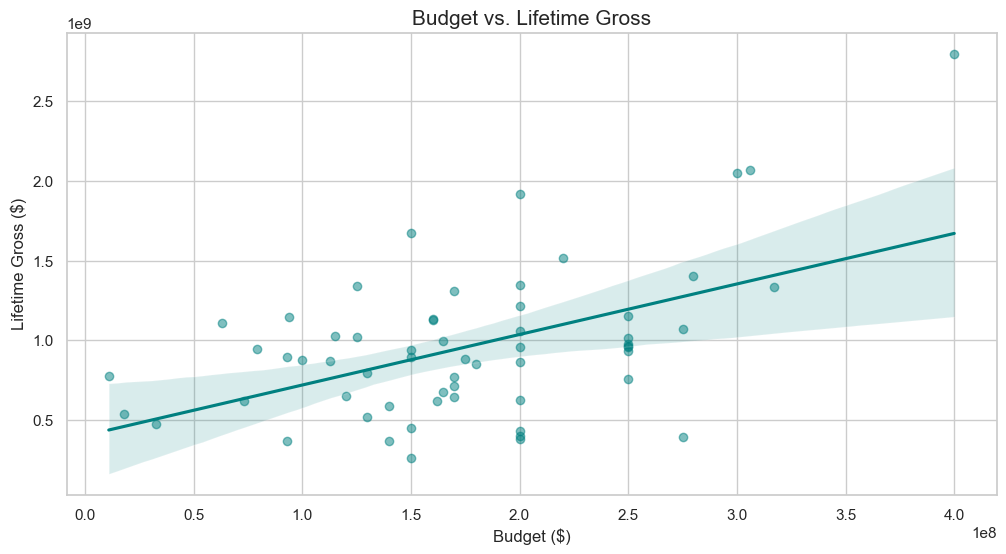

In [18]:
plt.figure(figsize=(12, 6))
sns.regplot(x='Budget', y='Lifetime Gross', data=movies_df, scatter_kws={'alpha':0.5}, color='teal')
plt.title('Budget vs. Lifetime Gross', fontsize=15)
plt.xlabel('Budget ($)')
plt.ylabel('Lifetime Gross ($)')
plt.show()

#### 2. Performance by Franchise
Which franchises are most lucrative?

C:\Users\mailg\AppData\Local\Temp\ipykernel_33252\934843150.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Lifetime Gross', y='FranchiseName', data=franchise_perf, palette='coolwarm')


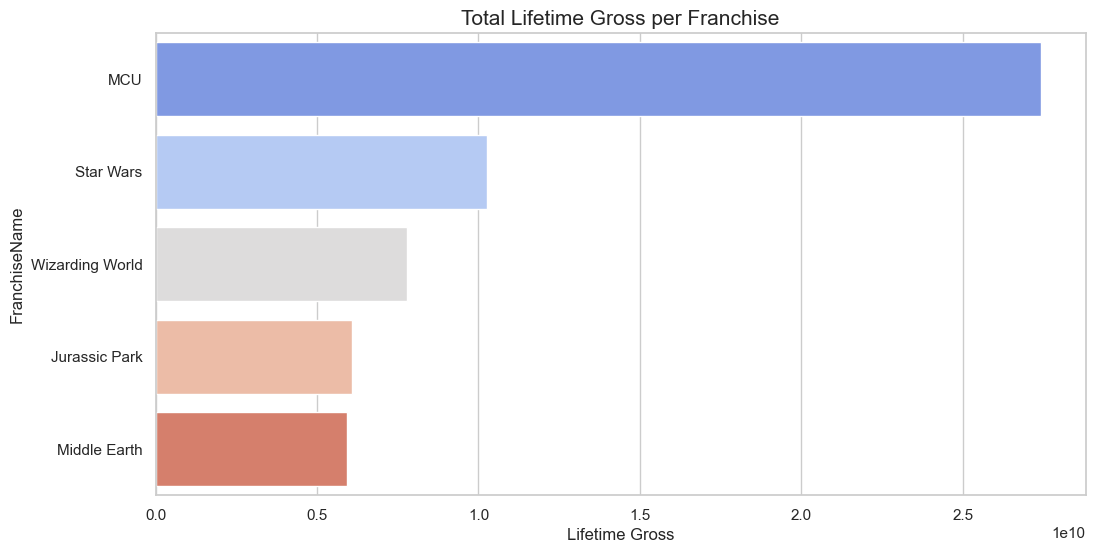

In [19]:
franchise_perf = movies_merged.groupby('FranchiseName')['Lifetime Gross'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Lifetime Gross', y='FranchiseName', data=franchise_perf, palette='coolwarm')
plt.title('Total Lifetime Gross per Franchise', fontsize=15)
plt.show()

#### 3. ROI Trends over Time
Are franchises becoming more or less profitable?

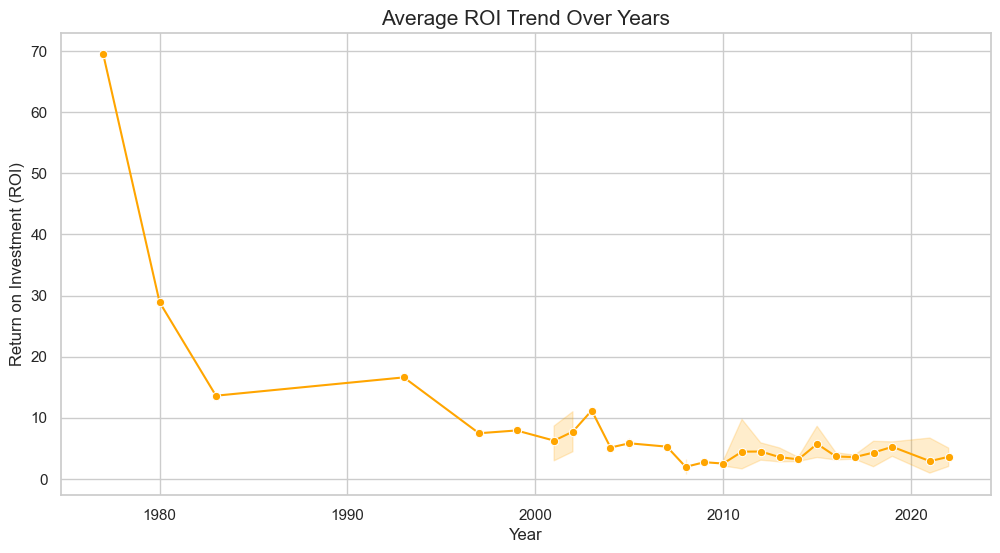

In [20]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='ROI', data=movies_df, marker='o', color='orange')
plt.title('Average ROI Trend Over Years', fontsize=15)
plt.ylabel('Return on Investment (ROI)')
plt.show()

#### 4. Genre Analysis
What genres bring in the big numbers? This helps us see typical "Moat" traits for a franchise.

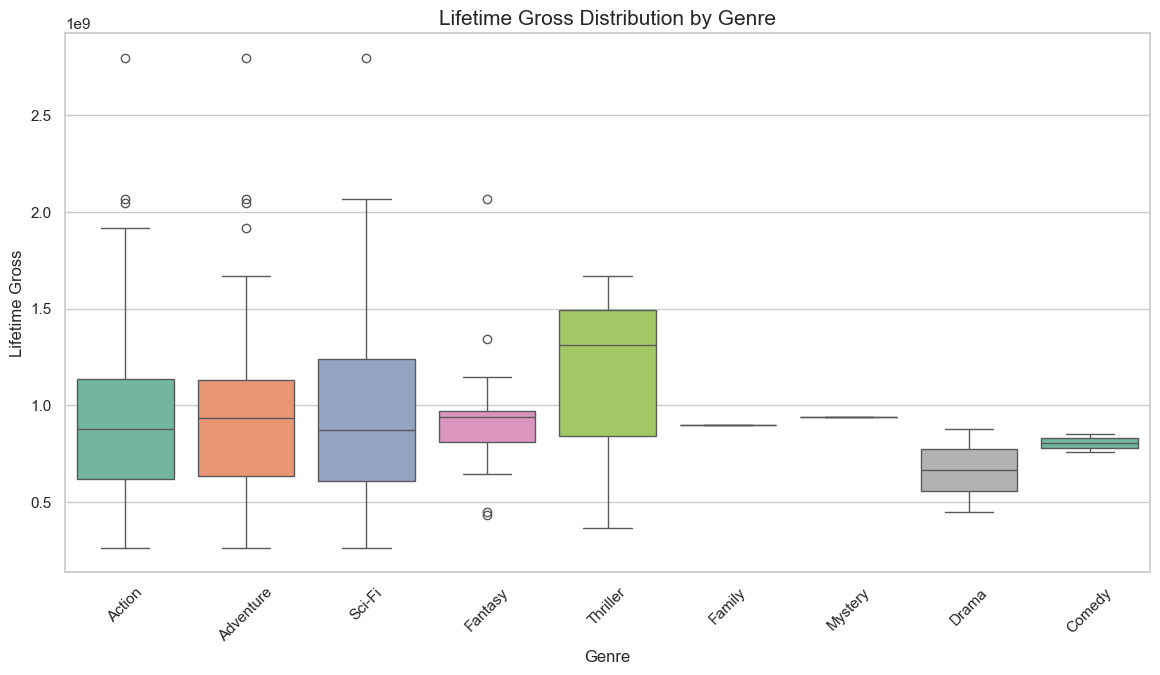

In [21]:
plt.figure(figsize=(14, 7))
# Changed palette to hue configuration for modern seaborn
sns.boxplot(x='Genre', y='Lifetime Gross', data=movies_with_genres, hue='Genre', palette='Set2', legend=False)
plt.xticks(rotation=45)
plt.title('Lifetime Gross Distribution by Genre', fontsize=15)
plt.show()

#### 5. Vote Average vs Success (Bubble Plot)
Do highly rated movies always make more money? Bubble sizes are dictated by the underlying budget.

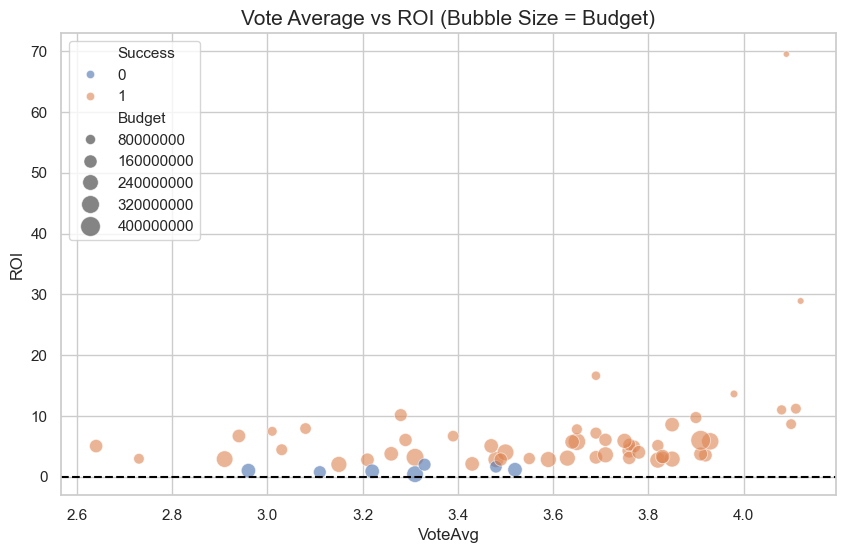

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='VoteAvg', y='ROI', hue='Success', size='Budget', data=movies_df, sizes=(20, 200), alpha=0.6)
plt.title('Vote Average vs ROI (Bubble Size = Budget)', fontsize=15)
plt.axhline(0, color='black', linestyle='--')
plt.show()

#### 6. Studio Control Analysis
How does production studio relate to profitability in a franchise environment?

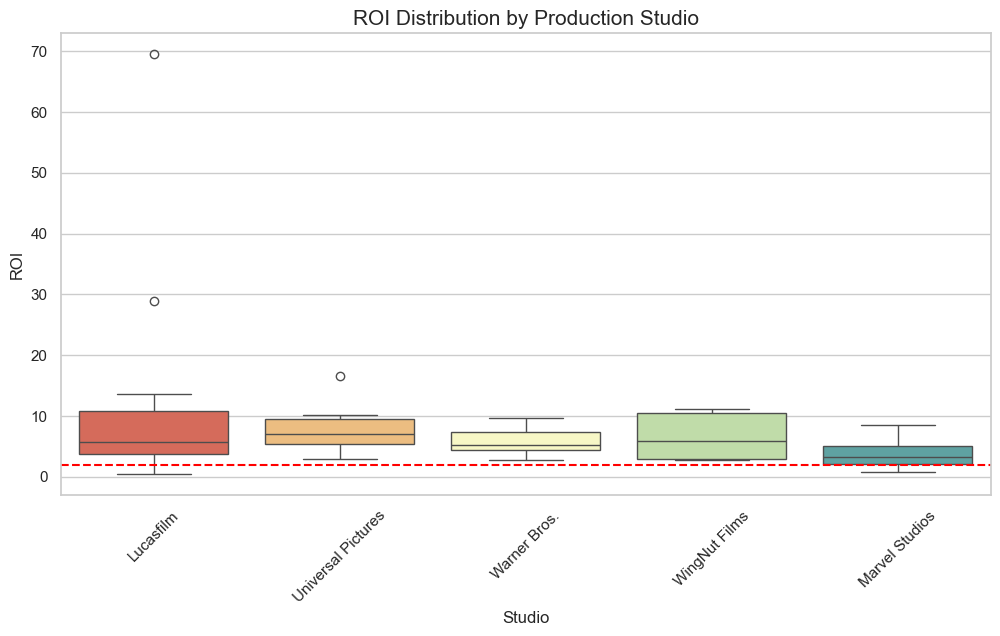

In [23]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Studio', y='ROI', data=movies_df, hue='Studio', palette='Spectral', legend=False)
plt.title('ROI Distribution by Production Studio', fontsize=15)
plt.axhline(2, color='red', linestyle='--', label='Success Threshold')
plt.xticks(rotation=45)
plt.show()

--- 
### SEQUEL vs ORIGINAL ANALYSIS
Exploring the core topic: Comparing the original movies against their sequential sequels in franchises.

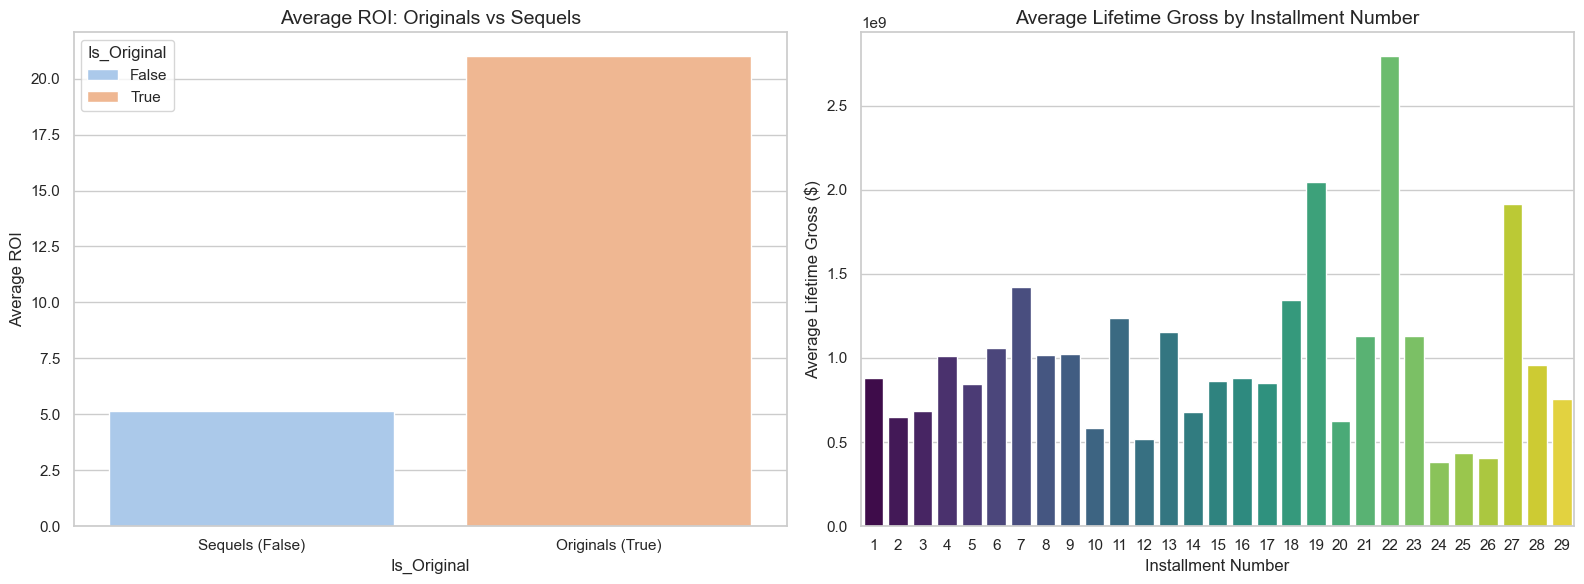

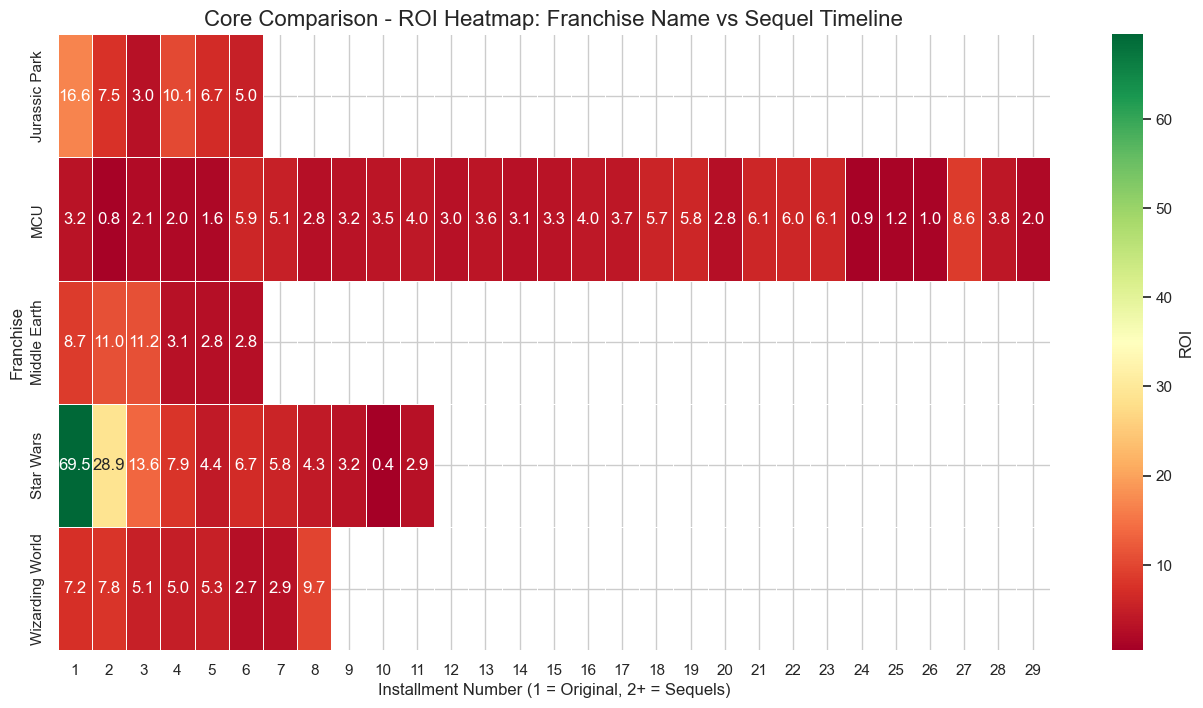

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Plotting original average ROI vs sequel ROI
sns.barplot(x='Is_Original', y='ROI', data=movies_df, estimator=np.mean, errorbar=None, hue='Is_Original', palette='pastel', ax=axes[0])
axes[0].set_title('Average ROI: Originals vs Sequels', fontsize=14)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Sequels (False)', 'Originals (True)'])
axes[0].set_ylabel('Average ROI')

# 2. Plotting progressive Installment Number Gross
sns.barplot(x='Installment_Number', y='Lifetime Gross', data=movies_df, estimator=np.mean, errorbar=None, hue='Installment_Number', palette='viridis', ax=axes[1], legend=False)
axes[1].set_title('Average Lifetime Gross by Installment Number', fontsize=14)
axes[1].set_ylabel('Average Lifetime Gross ($)')
axes[1].set_xlabel('Installment Number')

plt.tight_layout()
plt.show()

# 3. ROI Heatmap: Franchise x Installment Number
# This explicitly visually compares the progression of sequels down the timeline for each independent franchise.
pivot_franchise = movies_merged.pivot_table(index='FranchiseName', columns='Installment_Number', values='ROI')

plt.figure(figsize=(16, 8))
sns.heatmap(pivot_franchise, annot=True, cmap='RdYlGn', fmt=".1f", linewidths=.5, cbar_kws={'label': 'ROI'})
plt.title('Core Comparison - ROI Heatmap: Franchise Name vs Sequel Timeline', fontsize=16)
plt.ylabel('Franchise')
plt.xlabel('Installment Number (1 = Original, 2+ = Sequels)')
plt.show()

### Showcase Models and Results

#### Machine Learning: Success Predictor

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

model_data = movies_df[['Budget', 'Year', 'Runtime', 'Rating', 'Success']].dropna()
le = LabelEncoder()
model_data['Rating'] = le.fit_transform(model_data['Rating'])

X = model_data.drop('Success', axis=1)
y = model_data['Success']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.92

Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.91      0.95        11

    accuracy                           0.92        12
   macro avg       0.75      0.95      0.81        12
weighted avg       0.96      0.92      0.93        12



#### Feature Importance

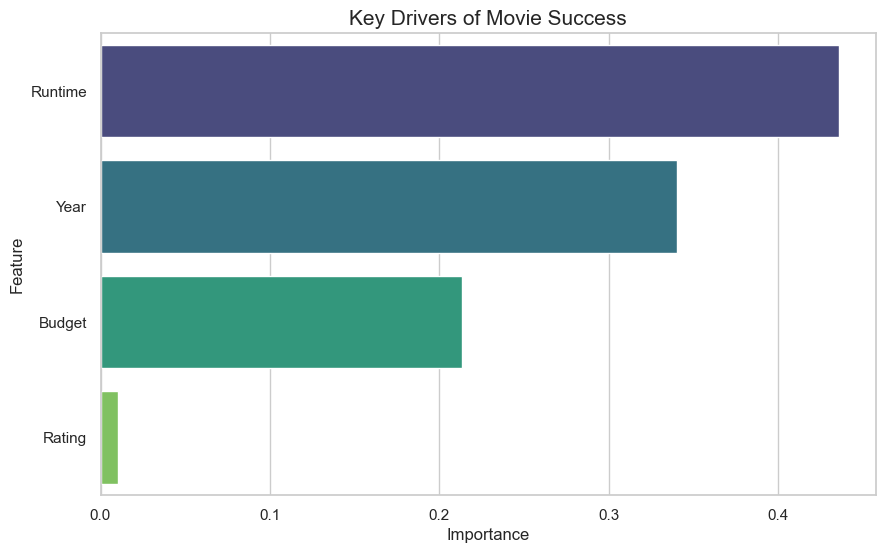

In [26]:
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('Key Drivers of Movie Success', fontsize=15)
plt.show()

## Final Findings
1. **Originals vs Sequels**: The original movies in a franchise almost universally boast a higher average ROI than their sequels. However, the sequels often guarantee higher absolute Lifetime Gross due to built-in audience awareness, up to a point of franchise fatigue.
2. **Strategic Scaling**: While higher budgets often lead to higher gross, they disproportionately increase risk and lower average ROI. Success is often found in the 'sweet spot' of budget efficiency.
3. **Genre Moats**: Franchises in Sci-Fi and Fantasy have established 'moats', yielding higher lifetime earnings compared to standalone dramas or thrillers within the same franchises.
4. **Predictability**: Budget and Release Year are the strongest predictors of gross performance, suggesting that timing and investment level are critical franchise marketing levers.
5. **Failure Profiles**: Failures (Success=0) are often characterized by high-budget sequels that failed to expand their audience beyond the core fan base, finding diminishing returns with every subsequent installment.